# taguchi_loss function demo

In [1]:
# Import libraries
from process_improvement.charts.taguchi_loss import taguchi_loss_function
from process_improvement.charts.utils import TaguchiLossConfig

from process_improvement.data_loader import list_example_files, load_example_data

%matplotlib inline

## Get data

In [2]:
# List example files
list_example_files()

['18650_battery_cells',
 '2170_battery_cell',
 'automated_manufacturing_part_lengths',
 'eight_machine_manufacturing_process',
 'milikans_electron_charge_observations',
 'monthly_united_states_trade_deficits_2024',
 'OP200_weekly_first_pass_yield',
 'quarterly_sales_by_region',
 'shewharts_resistance_measurements',
 'software_verification_death_to_birth_rates',
 'software_verification_resistance_measurement',
 'wafer_assembly_part_placement']

In [3]:
# Create dataframe
df = load_example_data("shewharts_resistance_measurements")

initial_df = df[df['Stage'] == 'Initial']

df.head()

,Stage,Units,Value,Resistance
0,Initial,megohms,1.0,5045.0
1,Initial,megohms,2.0,4350.0
2,Initial,megohms,3.0,4350.0
3,Initial,megohms,4.0,3975.0
4,Initial,megohms,5.0,4290.0


## Specification Limit

In [4]:
USL = 5295
LSL = 3395
tolerance = USL - LSL
target = LSL + (tolerance/2)

In [5]:
data = initial_df['Resistance']

## Taguchi Loss Configuration

In [11]:
# Configuration
config = TaguchiLossConfig(
    figsize=(15,5),
    show_grid = False,
    show_indices=False,
    align_ticks_with_bins='Centers',
    round_value=1,
    remove_all_spines=True,
    show_xtick_labels=False,
    show_label_values=False,
    show_mean_label=True,
    legend_round_value=2,
    histogram_color="tab:green"
)

## Taguchi Loss Function

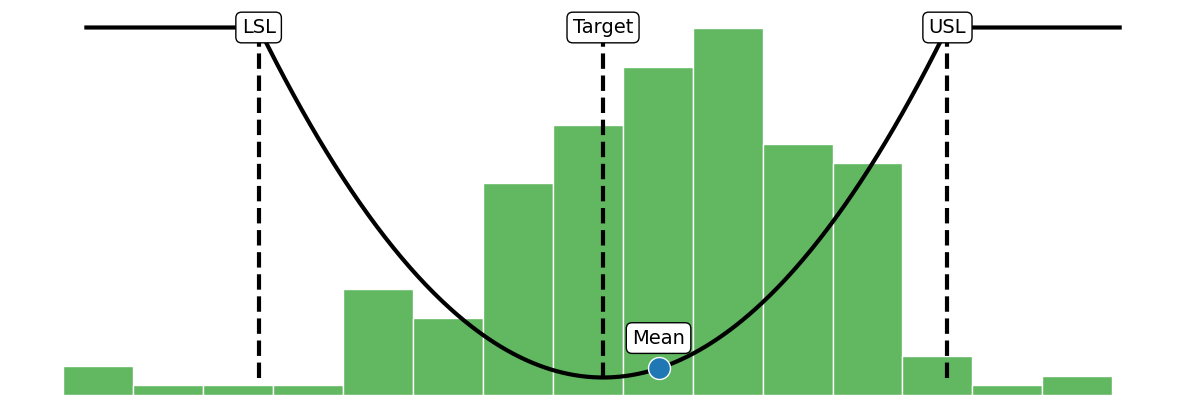

In [12]:
data = initial_df['Resistance']

# Create XmR chart
results = taguchi_loss_function(
    data=data,
    USL=USL,
    LSL=LSL,
    config=config
)

## Show process statistics

In [13]:
# Show statistics
results.stats_df

,Metric,Value
0,Mean,4498.18
1,UPL,5346.2
2,LPL,3650.2
3,URL,1041.8
4,Average mR,318.8
5,USL,5295
6,LSL,3395
7,Target,4345.0
8,Cp,1.120428
9,Cpk,0.939768


## Taguchi Loss Function 2

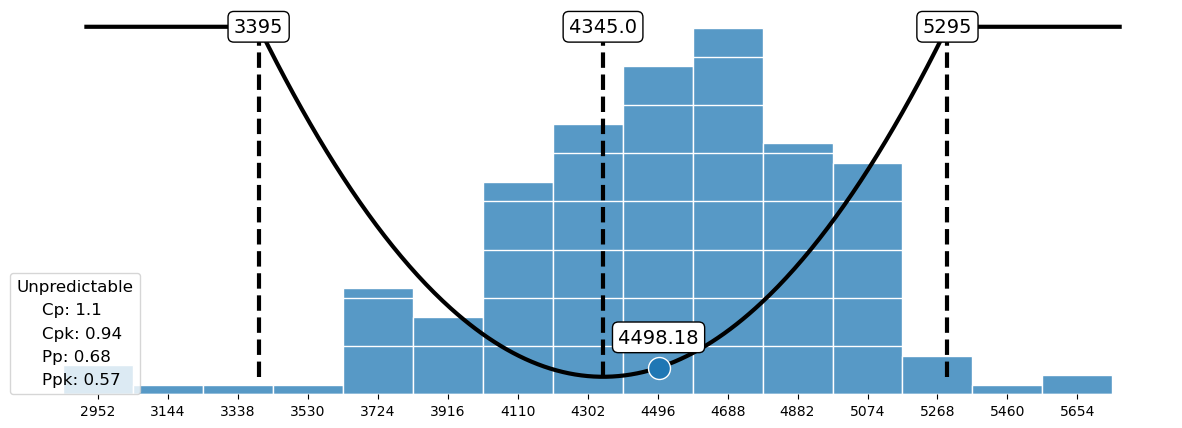

In [18]:
# Configuration
config2 = TaguchiLossConfig(
    figsize=(15,5),
    show_grid = True,
    show_indices=True,
    align_ticks_with_bins='Centers',
    round_value=3,
    remove_all_spines=True,
    show_xtick_labels=True,
    show_label_values=True,
    show_mean_label=True,
    legend_round_value=2,
    histogram_color="tab:blue"
)

# Specify the data
data = initial_df['Resistance']

# Create XmR chart
results = taguchi_loss_function(
    data=data,
    USL=USL,
    LSL=LSL,
    config=config2
)